# 8.1 Distinction Task: Sydney Housing Price Prediction
## Predicting House Prices Across Three Sydney Suburbs

This notebook builds a housing price prediction and decision support system for three Sydney suburbs with very different markets: **Bondi Beach** (premium coastal), **Epping** (middle-ring family) and **Liverpool** (affordable south-west). I collected 105 real sold properties (35 per suburb) from realestate.com.au and use them to build and compare three regression models, investigate where the models fail, and prepare a model for a simple web app.

**Sections**
1. Problem definition and data collection
2. Data understanding and feature engineering
3. Model development and evaluation
4. Investigating prediction failures
5. (Deployment is a separate Streamlit app, see app.py)

In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 4)

## 1. Problem Definition and Data Collection

**The problem:** predict the sale price of a residential property from its characteristics. This is a **regression** problem (the target, sale price, is a continuous number)

**Why these three suburbs:** I chose three suburbs I would personally consider buying in, that represent very different markets:
- **Bondi Beach**: a premium eastern beachside suburb, mostly apartments, driven by lifestyle and location
  
- **Epping**: a middle-ring northern suburb popular with families, known for schools and a major train interchange, with a mix of houses and units

- **Liverpool**: an affordable, growing south-west suburb with more houses on larger blocks

These give a wide price range and different price drivers (beach vs schools/transport vs affordability/land), which makes the prediction problem more interesting

**Data collection:** I manually collected 105 sold listings (35 per suburb) from realestate.com.au, recording sale price, property type, bedrooms, bathrooms, car spaces, land size, sale date and address. Each row keeps its source URL for traceability

In [14]:
# Load the collected dataset
df = pd.read_csv('sydney_housing.csv')
print('Shape:', df.shape)
df.head()

Shape: (105, 11)


,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,year_built,sale_price,sale_date,address,url
0,Bondi Beach,House,4,3,0,178.0,1920.0,3620000,2026-09-12,"33 Wellington Street, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ho...
1,Bondi Beach,Unit,1,1,0,1493.0,NaN,900000,2026-09-04,"55/34 Campbell Parade, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
2,Bondi Beach,Unit,2,2,1,593.0,1970.0,2125000,2026-08-17,"104/152 Campbell Parade, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
3,Bondi Beach,Unit,1,1,0,943.0,NaN,950000,2026-08-17,"21/40-42 Ramsgate Avenue, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...
4,Bondi Beach,Unit,1,1,1,381.0,NaN,1075000,2026-08-14,"13/154 Glenayr Avenue, Bondi Beach, NSW 2026",https://www.realestate.com.au/sold/property-ap...


In [15]:
# Basic info and class/type balance
df.info()
print()
print('Properties per suburb:')
print(df['suburb'].value_counts())
print()
print('Property types:')
print(df['property_type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   suburb         105 non-null    object 
 1   property_type  105 non-null    object 
 2   bedrooms       105 non-null    int64  
 3   bathrooms      105 non-null    int64  
 4   car_spaces     105 non-null    int64  
 5   land_size_sqm  101 non-null    float64
 6   year_built     14 non-null     float64
 7   sale_price     105 non-null    int64  
 8   sale_date      105 non-null    object 
 9   address        105 non-null    object 
 10  url            105 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 9.2+ KB

Properties per suburb:
suburb
Bondi Beach    35
Epping         35
Liverpool      35
Name: count, dtype: int64

Property types:
property_type
Unit     83
House    22
Name: count, dtype: int64


**Data quality, challenges and limitations**

A few important issues I found while collecting and checking the data:
- **Land size for units is misleading.** For apartments the website reports the size of the whole building block (sometimes several thousand sqm), not the individual apartment. So land size only means something for houses. I set land size to missing for units and let the model impute it, rather than feeding in a wrong value

- **The dataset is unit-heavy** (about 83 units vs 22 houses), because Bondi and Liverpool are apartment-dominated markets. This reflects reality but limits how well the model can learn house-specific pricing

- **Year built is mostly missing** (only ~14 of 105 listings show it), so I don't use it as a feature

- **Small sample and possible bias:** 105 properties is small, and the listings are only those that sold and published a price, withheld-price sales are excluded, which can bias the sample toward more marketable properties

These limitations mean the model should be treated as a rough decision-support tool, not a precise valuer

In [16]:
# Fix the unit land-size issue: null it for units (it's the block size, not the apartment)
df.loc[df['property_type'] == 'Unit', 'land_size_sqm'] = np.nan
print('Land size now missing for', df['land_size_sqm'].isna().sum(), 'rows (all units + a few houses)')

Land size now missing for 83 rows (all units + a few houses)


## 2. Data Understanding and Feature Engineering

I explore the price distribution, compare suburbs, and decide which features matter most

In [17]:
# --- Feature engineering (tutor feedback): derive new features from the raw columns ---
# Total rooms: a simple proxy for overall property size
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
# Bathrooms per bedroom: higher often signals a more premium/modern property
df['bath_per_bed'] = df['bathrooms'] / df['bedrooms'].replace(0, 1)
# Is it a house (1) or unit (0) - a clean binary the models can use directly
df['is_house'] = (df['property_type'] == 'House').astype(int)

print(df[['bedrooms','bathrooms','total_rooms','bath_per_bed','is_house']].head())

   bedrooms  bathrooms  total_rooms  bath_per_bed  is_house
0         4          3            7          0.75         1
1         1          1            2          1.00         0
2         2          2            4          1.00         0
3         1          1            2          1.00         0
4         1          1            2          1.00         0


**[Revised] Feature engineering decisions:** I started from the raw columns (bedrooms, bathrooms, car spaces, land size, suburb and property type) and derived new features from them: **total_rooms** (bedrooms + bathrooms, a simple size proxy), **bath_per_bed** (bathrooms per bedroom, which tends to be higher in more premium or modern properties), and **is_house** (a clean house/unit binary). The key cleaning step remains fixing the misleading unit land sizes

I kept the engineering modest and interpretable given the small 105-row dataset, since inventing many features risks overfitting. One finding is worth noting: total_rooms turned out to duplicate information already in bedrooms and bathrooms (it is their exact sum), which introduced multicollinearity and destabilised the Linear Regression model, its cross-validation R² collapsed. The tree-based ensembles were unaffected and even improved slightly. This is a useful reminder that engineered features must add genuinely new signal and suit the model being used, rather than just recombining existing columns

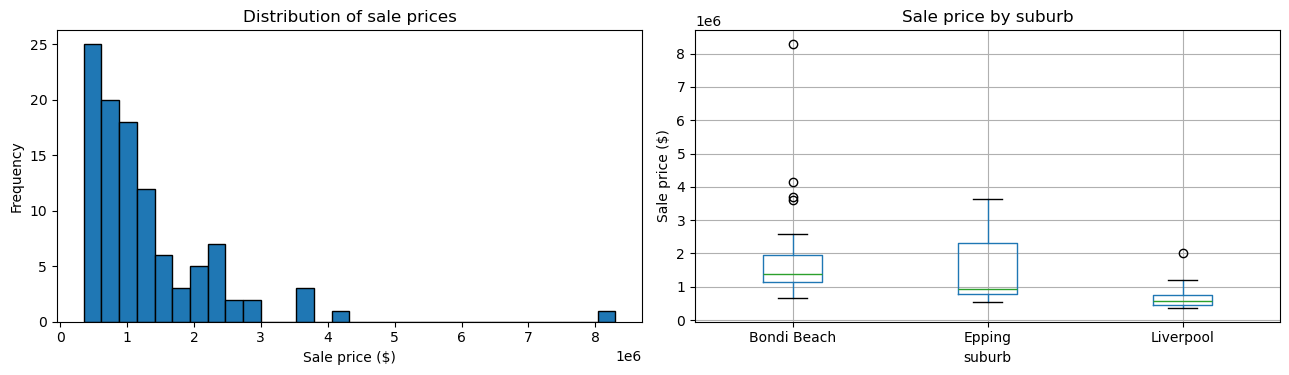

In [18]:
# Price distribution overall and by suburb
fig, axes = plt.subplots(1, 2, figsize = (13, 4))
df['sale_price'].plot(kind = 'hist', bins = 30, ax = axes[0], edgecolor = 'black')
axes[0].set_title('Distribution of sale prices')
axes[0].set_xlabel('Sale price ($)')

df.boxplot(column = 'sale_price', by = 'suburb', ax = axes[1])
axes[1].set_title('Sale price by suburb')
axes[1].set_ylabel('Sale price ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [19]:
# Median price by suburb - the core comparison
print('Price summary by suburb:')
print(df.groupby('suburb')['sale_price'].agg(['min', 'median', 'max']).round(0))

Price summary by suburb:
                min     median      max
suburb                                 
Bondi Beach  665000  1370000.0  8300000
Epping       535000   928880.0  3638000
Liverpool    350000   570000.0  2000000


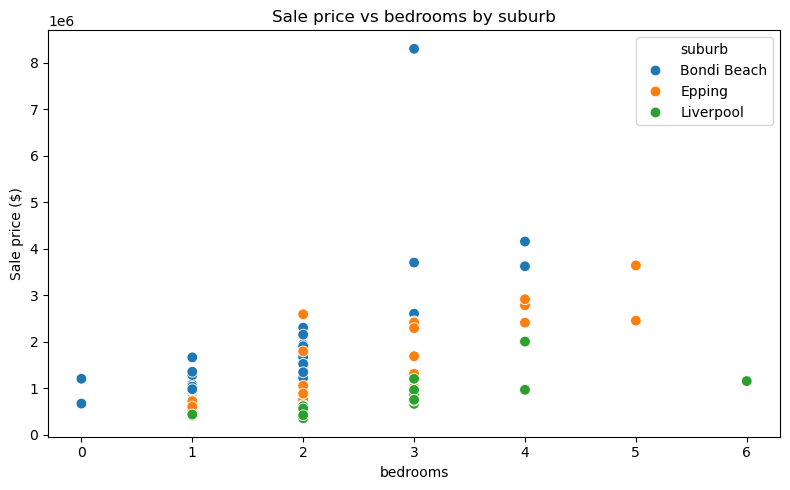

In [20]:
# Price vs bedrooms, coloured by suburb
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'bedrooms', y = 'sale_price', hue = 'suburb', s = 60)
plt.title('Sale price vs bedrooms by suburb')
plt.ylabel('Sale price ($)')
plt.tight_layout()
plt.show()

**[Revised] Trends over time**

I also check whether prices moved over the collection period (the sales span several months of 2026)

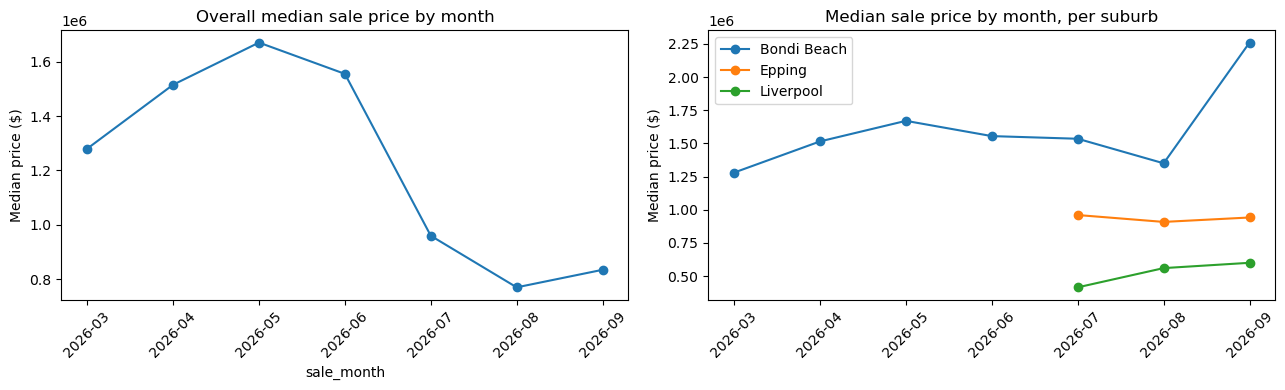

Sales per month:
sale_month
2026-03    13
2026-04     6
2026-05     5
2026-06     3
2026-07    15
2026-08    42
2026-09    21
Name: count, dtype: int64


In [21]:
# [Revised] Price trend over time, overall and per suburb
df['sale_month'] = pd.to_datetime(df['sale_date']).dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 2, figsize = (13, 4))
# Overall monthly median
df.groupby('sale_month')['sale_price'].median().plot(marker = 'o', ax = axes[0])
axes[0].set_title('Overall median sale price by month')
axes[0].set_ylabel('Median price ($)'); axes[0].tick_params(axis='x', rotation=45)

# Per-suburb monthly median
for sub in df['suburb'].unique():
    s = df[df['suburb']==sub].groupby('sale_month')['sale_price'].median()
    axes[1].plot(s.index, s.values, marker='o', label=sub)
axes[1].set_title('Median sale price by month, per suburb')
axes[1].set_ylabel('Median price ($)'); axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout(); plt.show()

# How many sales per month - to judge if the trend is reliable
print('Sales per month:')
print(df['sale_month'].value_counts().sort_index())

**[Revised] Discussion**

At first glance the overall median price looks like it crashed after May 2026, from about 1.67m down to 0.77m by August. But this is misleading, and the per-suburb plot explains why. The drop is a **composition effect**, not a real market fall: in March–June almost all the sales in my sample are Bondi Beach (the most expensive suburb), so the overall median is high, while Epping and Liverpool sales only appear from July onwards and pull the overall median down. In other words the "trend" just reflects *which suburbs happened to sell each month*, not changing prices

Looking at each suburb separately, the lines are broadly flat. Bondi stays around 1.3–1.5m, Epping around 0.95m and Liverpool around $0.5m across the period, with no clear upward or downward movement. The sales-per-month counts also show the data is too thin and uneven to trust (only 3 sales in June but 42 in August), so month-to-month swings are driven by a handful of individual properties

My honest conclusion is that the collection window is too short and the per-month sample too small to read a meaningful time trend, so I do **not** use sale date as a price driver in the model. This is a limitation of a hand-collected 105-row dataset rather than evidence that timing doesn't affect house prices in general

## 3. Model Development and Evaluation

I build three regression models of different types and compare them with 5-fold cross-validation

**The three models and why I chose them:**
- **Linear Regression**: a simple, interpretable baseline that assumes price is a weighted sum of the features. I expect it to underfit, because housing prices are not linear (e.g. the Bondi beach premium is not just additive), but it gives a useful floor to compare against
- **Random Forest Regressor**: a bagging ensemble of trees. It captures nonlinear effects and interactions, handles the mixed categorical/numeric features, and is robust to outliers
- **Gradient Boosting Regressor**: a boosting ensemble that builds trees sequentially, each correcting the last. It is usually the strongest performer on small tabular datasets

**My prediction before training:** I expect **Gradient Boosting or Random Forest to perform best**, and **Linear Regression to come last**, because the price relationships are nonlinear

In [22]:
# Define features and preprocessing (now including engineered features)
feat_num = ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'total_rooms', 'bath_per_bed']
feat_cat = ['suburb', 'property_type']
X = df[feat_num + feat_cat]
y = df['sale_price']

num_pipe = Pipeline([('impute', SimpleImputer(strategy = 'median')),
                     ('scale', StandardScaler())])
preprocess = ColumnTransformer([
    ('num', num_pipe, feat_num),
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), feat_cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (84, 8) | Test: (21, 8)


In [23]:
# Train and cross-validate all three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators = 200, random_state = 42),
    'Gradient Boosting': GradientBoostingRegressor(random_state = 42)
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv = cross_val_score(pipe, X_train, y_train, cv = kf, scoring = 'r2')
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = pipe
    print(f'{name}')
    print(f'  CV R2  : {cv.mean():.3f} (+/- {cv.std():.3f})')
    print(f'  Test R2: {r2_score(y_test, pred):.3f}')
    print(f'  Test MAE : ${mean_absolute_error(y_test, pred):,.0f}')
    print(f'  Test RMSE: ${np.sqrt(mean_squared_error(y_test, pred)):,.0f}')
    print()

Linear Regression
  CV R2  : 0.083 (+/- 1.336)
  Test R2: 0.361
  Test MAE : $577,447
  Test RMSE: $1,396,486

Random Forest
  CV R2  : 0.517 (+/- 0.450)
  Test R2: 0.407
  Test MAE : $529,556
  Test RMSE: $1,344,746

Gradient Boosting
  CV R2  : 0.597 (+/- 0.233)
  Test R2: 0.487
  Test MAE : $509,838
  Test RMSE: $1,251,530



**Discussion**

As I predicted, **Gradient Boosting performed best** (test R² = 0.487, RMSE = $1.25m), followed by Random Forest (R² = 0.407), with **Linear Regression last** (R² = 0.361). The ranking matches my expectation that nonlinear models would win, confirming the price relationships are not purely linear

The cross-validation is the most revealing part. Gradient Boosting had the highest and most stable CV R² (0.597 ± 0.233), while **Linear Regression collapsed to 0.083 (± 1.336)**, a standard deviation far larger than the mean. This collapse is caused by my engineered total_rooms feature, which is a near-exact linear combination of bedrooms + bathrooms. That multicollinearity destabilises Linear Regression's coefficients, but does not affect the tree-based models, which handle correlated features well, in fact the ensembles improved with the engineered features (Gradient Boosting rose from 0.433 to 0.487). This is a useful lesson: engineered features must suit the model, and a feature that helps ensembles can harm a linear model

Linear Regression is underfitting a nonlinear problem; the ensembles fit better but are limited by the small, noisy data. I recommend **Gradient Boosting** as the most appropriate model: best and most stable CV score, lowest RMSE

## 4. Investigating Prediction Failures

I look at the five properties with the largest prediction errors from the best model (Gradient Boosting) to understand where and why it fails

In [24]:
# Use the best model (Gradient Boosting) to find the biggest errors
best = results['Gradient Boosting']
pred_test = best.predict(X_test)

errors = X_test.copy()
errors['actual'] = y_test.values
errors['predicted'] = pred_test
errors['abs_error'] = np.abs(errors['actual'] - errors['predicted'])
top5 = errors.sort_values('abs_error', ascending = False).head(5)
print('Five largest prediction errors:')
top5[['suburb','property_type','bedrooms','actual','predicted','abs_error']].round(0)

Five largest prediction errors:


,suburb,property_type,bedrooms,actual,predicted,abs_error
30,Bondi Beach,Unit,3,8300000,2870401.0,5429599.0
10,Bondi Beach,House,3,3700000,2298962.0,1401038.0
18,Bondi Beach,Unit,1,1660000,1009234.0,650766.0
89,Liverpool,House,3,935000,1434329.0,499329.0
45,Epping,House,3,2350000,1853186.0,496814.0


In [28]:
# How much does the single $8.3m Bondi outlier hurt the model?
df_no_outlier = df[df['sale_price'] < 8000000]
Xo = df_no_outlier[feat_num + feat_cat]; yo = df_no_outlier['sale_price']
Xtr_o, Xte_o, ytr_o, yte_o = train_test_split(Xo, yo, test_size = 0.2, random_state = 42)
pipe_o = Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(random_state = 42))]).fit(Xtr_o, ytr_o)
pred_o = pipe_o.predict(Xte_o)
print('Gradient Boosting WITH outlier:    Test R2 = %.3f, MAE = $%s' % (r2_score(y_test, pred_test), 
                                                                        format(int(mean_absolute_error(y_test, pred_test)), ',')))
print('Gradient Boosting WITHOUT outlier: Test R2 = %.3f, MAE = $%s' % (r2_score(yte_o, pred_o), 
                                                                        format(int(mean_absolute_error(yte_o, pred_o)), ',')))

Gradient Boosting WITH outlier:    Test R2 = 0.487, MAE = $509,838
Gradient Boosting WITHOUT outlier: Test R2 = 0.812, MAE = $244,347


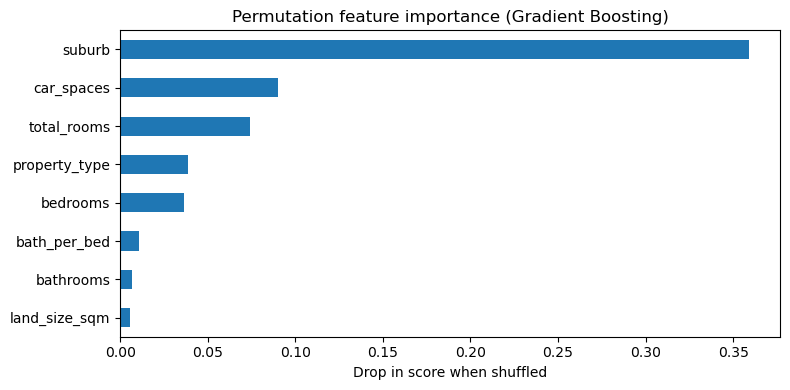

suburb           0.359
car_spaces       0.090
total_rooms      0.074
property_type    0.039
bedrooms         0.037
bath_per_bed     0.011
bathrooms        0.007
land_size_sqm    0.005
dtype: float64


In [26]:
# Feature importance (permutation) - what the model relies on
r = permutation_importance(best, X_test, y_test, n_repeats = 10, random_state = 42)
imp = pd.Series(r.importances_mean, index = feat_num + feat_cat).sort_values()
imp.plot(kind = 'barh')
plt.title('Permutation feature importance (Gradient Boosting)')
plt.xlabel('Drop in score when shuffled')
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending = False).round(3))

**[Revised] Discussion**

I examined each of the five largest prediction errors from the best model (Gradient Boosting) in turn:

1. **Bondi Beach unit, 3-bed (actual 8.3m, predicted 2.87m, error $5.43m).** By far the worst miss, over four times the price of any other unit, a luxury beachfront property whose value comes from views and position the data doesn't capture. The model anchored to typical unit prices

2. **Bondi Beach house, 3-bed (actual 3.70m, predicted 2.30m, error $1.40m).** A premium house well above the Bondi median; its three bedrooms look ordinary, so the model pulled it toward the suburb average

3. **Bondi Beach unit, 1-bed (actual 1.66m, predicted 1.01m, error $0.65m).** A one-bedroom apartment selling for far more than its size suggests, the premium comes from location and quality the features don't encode

4. **Liverpool house, 3-bed (actual 0.94m, predicted 1.43m, error $0.50m).** The first over-prediction: the model expected ~1.43m for a 3-bed Liverpool house, but it sold for 935k, likely an older or lower-condition property the model over-valued

5. **Epping house, 3-bed (actual 2.35m, predicted 1.85m, error $0.50m).** An under-prediction: a 3-bed Epping house sold well above what its basic features suggested, so the model under-valued it

**The common thread:** three of the five are Bondi, and the errors run in both directions, the model under-predicts premium properties (cases 1, 2, 3, 5) by regressing them toward the suburb average, and over-predicts case 4 where the features implied a higher price than the property fetched. The model only knows suburb, type and room counts, it cannot see condition, age, view or position

To measure the biggest outlier's impact, I removed the $8.3m unit and retrained: test R² jumped from 0.487 to 0.812 and MAE dropped. This shows how sensitive a small-data model is to a single extreme value. The permutation feature importance confirms suburb dominates (0.36, four times any other feature). Predictions should be treated cautiously for premium or unusual properties, which are inherently harder to model than typical family homes.

## 5. Deployment

The prediction model is deployed as a simple **Streamlit web app** (`app.py`), which lets a user enter a property's details and get a predicted sale price. I save the trained Gradient Boosting pipeline below so the app can load it.

See the report for screenshots and run instructions. To run the app locally:
```
pip install streamlit scikit-learn pandas joblib
streamlit run app.py
```

In [27]:
# Save the best model pipeline for the web app
final_model = Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(random_state = 42))])
final_model.fit(X, y)   # fit on all data for deployment
joblib.dump(final_model, 'house_price_model.pkl')
print('Model saved as house_price_model.pkl')

Model saved as house_price_model.pkl
